# Benchmark Model Training

### Logistic Regression, Random Forest, XGBoost


## Logistic Regression (Mean Rating)


In [1]:
import sys
from pathlib import Path

# Add project root to path
sys.path.append(str(Path("..").resolve()))


from helpers import ModelData
from constants import PROCESSED_DATA_FOLDER
import numpy as np

model_data = ModelData.from_pickle(PROCESSED_DATA_FOLDER / "processed_data.pkl")
model_data

/Users/omidsedighi-mornani/Desktop/STUDIUM WIRTSCHAFTSINFORMATIK/Semester 5/Seminar Gust/SourceCode/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ModelData(n_total=921, n_train=500, n_obs=64887)

In [2]:
# Random Seed für Reproduzierbarkeit
SEED = 42

In [3]:
# Aufteilung in business_covariates und rating_stats

# Business covariates (ohne Rating-Statistiken und OHNE Closed!)
business_features = [
    "density",
    "Checkin",
    "category",
    "chain",
    "Price.Level",
    "Restaurant.Size",
    "Number.of.Seats",
    "ZRI",
    "Distance.To.City.Centre",
    "Age",
]

# Rating statistics
rating_features = [
    "VAR",
    "MEAN",
    "ENTR",
    "COUNT",
    "ONE_STAR",
    "TWO_STAR",
    "THREE_STAR",
    "FOUR_STAR",
    "FIVE_STAR",
    "l_COUNT",
]

print(f"Business features: {len(business_features)} Variablen")
print(f"Rating features: {len(rating_features)} Variablen")
print(f"Gesamt: {len(business_features) + len(rating_features)} Variablen")

# Train/Test Split basierend auf train_indices
train_indices = model_data.train_indices

# Eval und Calibration Indizes (beziehen sich auf den gesamten Datensatz)
eval_indices = model_data.eval_indices
calibration_indices = model_data.calibration_indices

print(f"\nTrain/Test Split:")
print(f"  Training samples: {len(train_indices)}")
print(f"  Eval samples: {len(eval_indices)}")
print(f"  Calibration samples: {len(calibration_indices)}")
print(f"  Total: {len(train_indices) + len(eval_indices) + len(calibration_indices)}")

Business features: 10 Variablen
Rating features: 10 Variablen
Gesamt: 20 Variablen

Train/Test Split:
  Training samples: 500
  Eval samples: 321
  Calibration samples: 100
  Total: 921


## Datenvorbereitungen für alle Modelle


In [4]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Target Variable vorbereiten (für alle Daten)
y = model_data.benchmark_covariates["Closed"].map({"Open": 0, "Closed": 1}).values

# ============================================================================
# 1. X_mean: Nur Mean Rating
# ============================================================================
X_mean = model_data.benchmark_covariates[["MEAN"]].values

# ============================================================================
# 2. X_business: Business Covariates (mit Preprocessing)
# ============================================================================
df_business = model_data.benchmark_covariates[business_features].copy()

# Kategorische Variablen identifizieren
categorical_cols = ["category"]
numeric_cols = [col for col in business_features if col not in categorical_cols]

# One-Hot Encoding
df_business_encoded = pd.get_dummies(
    df_business, columns=categorical_cols, drop_first=True
)

# Imputation und Standardisierung (nur auf Train-Daten fitten!)
imputer_business = SimpleImputer(strategy="median")
scaler_business = StandardScaler()

# Train-Daten preprocessing
numeric_train = df_business_encoded.iloc[train_indices][numeric_cols]
imputer_business.fit(numeric_train)
scaler_business.fit(imputer_business.transform(numeric_train))

# Transform für alle Daten
numeric_data_imputed = imputer_business.transform(df_business_encoded[numeric_cols])
numeric_data = scaler_business.transform(numeric_data_imputed)

# Kombiniere Features
X_business = pd.DataFrame(
    numeric_data, columns=numeric_cols, index=df_business_encoded.index
)
dummy_cols = [col for col in df_business_encoded.columns if col not in numeric_cols]
X_business = pd.concat([X_business, df_business_encoded[dummy_cols]], axis=1)

# ============================================================================
# 3. X_all: Alle Variablen (Business Covariates + Rating Stats)
# ============================================================================
all_features = business_features + rating_features

# Daten vorbereiten
df_all = model_data.benchmark_covariates[all_features].copy()

# Kategorische Variablen
categorical_cols = ["category"]
numeric_cols = [col for col in all_features if col not in categorical_cols]

# One-Hot Encoding
df_all_encoded = pd.get_dummies(df_all, columns=categorical_cols, drop_first=True)

# Imputation und Standardisierung (nur auf Train-Daten fitten!)
imputer_all = SimpleImputer(strategy="median")
scaler_all = StandardScaler()

# Train-Daten preprocessing
numeric_train = df_all_encoded.iloc[train_indices][numeric_cols]
imputer_all.fit(numeric_train)
scaler_all.fit(imputer_all.transform(numeric_train))

# Transform für alle Daten
numeric_data_imputed = imputer_all.transform(df_all_encoded[numeric_cols])
numeric_data = scaler_all.transform(numeric_data_imputed)

# Kombiniere Features
X_all = pd.DataFrame(numeric_data, columns=numeric_cols, index=df_all_encoded.index)
dummy_cols = [col for col in df_all_encoded.columns if col not in numeric_cols]
X_all = pd.concat([X_all, df_all_encoded[dummy_cols]], axis=1)

# ============================================================================
# Train Split (für das Training)
# ============================================================================
X_mean_train = X_mean[train_indices]
X_business_train = X_business.iloc[train_indices]
X_all_train = X_all.iloc[train_indices]
y_train = y[train_indices]

# ============================================================================
# Zusammenfassung
# ============================================================================
print()
print("DATENVORBEREITUNGEN ABGESCHLOSSEN")
print("=" * 80)
print(f"\nTarget Variable (y):")
print(f"  Total samples: {len(y)} (Closed: {sum(y)}, Open: {len(y) - sum(y)})")
print(
    f"  Train samples: {len(y_train)} (Closed: {sum(y_train)}, Open: {len(y_train) - sum(y_train)})"
)

print(f"\nFeature Sets:")
print(f"  X_mean:     {X_mean.shape} (Train: {X_mean_train.shape})")
print(f"  X_business: {X_business.shape} (Train: {X_business_train.shape})")
print(f"  X_all:      {X_all.shape} (Train: {X_all_train.shape})")

print(f"\nFeature Details:")
print(f"  Mean Rating: 1 Variable")
print(
    f"  Business Covariates: {len(X_business.columns)} Variablen (nach One-Hot Encoding)"
)
print(f"  All Features: {len(X_all.columns)} Variablen (nach One-Hot Encoding)")


DATENVORBEREITUNGEN ABGESCHLOSSEN

Target Variable (y):
  Total samples: 921 (Closed: 225, Open: 696)
  Train samples: 500 (Closed: 127, Open: 373)

Feature Sets:
  X_mean:     (921, 1) (Train: (500, 1))
  X_business: (921, 17) (Train: (500, 17))
  X_all:      (921, 27) (Train: (500, 27))

Feature Details:
  Mean Rating: 1 Variable
  Business Covariates: 17 Variablen (nach One-Hot Encoding)
  All Features: 27 Variablen (nach One-Hot Encoding)


## Model 1: Logistic Regression mit Mean Rating


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from helpers.benchmark_helpers import get_model_performance

# Train Logistic Regression auf X_train
lr_mean = LogisticRegression(random_state=SEED, max_iter=1000)
lr_mean.fit(X_mean_train, y_train)

# Predictions auf ALLE Daten (inkl. Train, Calibration und Eval)
y_proba_mean = lr_mean.predict_proba(X_mean)[:, 1]

# Performance Metrics mit get_model_performance
perf_lr_mean = get_model_performance(
    y_prob=y_proba_mean,
    y_exp=y,
    calibration_indices=calibration_indices,
    eval_indices=eval_indices,
)

## Model 2: Logistic Regression mit Business Covariates


In [6]:
# Train Logistic Regression auf X_train
lr_business = LogisticRegression(random_state=SEED, max_iter=1000)
lr_business.fit(X_business_train, y_train)

# Predictions auf ALLE Daten
y_proba_business = lr_business.predict_proba(X_business)[:, 1]

# Performance Metrics mit get_model_performance
perf_lr_business = get_model_performance(
    y_prob=y_proba_business,
    y_exp=y,
    calibration_indices=calibration_indices,
    eval_indices=eval_indices,
)

## Model 3: Logistic Regression mit allen Variablen (Business + Rating Stats)


In [7]:
# Train Logistic Regression auf X_train
lr_all = LogisticRegression(random_state=SEED, max_iter=1000)
lr_all.fit(X_all_train, y_train)

# Predictions auf ALLE Daten
y_proba_all = lr_all.predict_proba(X_all)[:, 1]

# Performance Metrics mit get_model_performance
perf_lr_all = get_model_performance(
    y_prob=y_proba_all,
    y_exp=y,
    calibration_indices=calibration_indices,
    eval_indices=eval_indices,
)

## Vergleich der drei Benchmark-Modelle


# Random Forest Models

---


## Model 4: Random Forest mit Mean Rating


In [8]:
from sklearn.ensemble import RandomForestClassifier

# Model 4: Random Forest mit Mean Rating
# Parameter aus Original-Paper (3_analysis.R, Zeile 509-518)
rf_mean = RandomForestClassifier(
    random_state=SEED, n_estimators=500, max_leaf_nodes=9  # ntree = 500  # maxnodes = 9
)
rf_mean.fit(X_mean_train, y_train)

# Predictions auf ALLE Daten
y_proba_rf_mean = rf_mean.predict_proba(X_mean)[:, 1]

# Performance Metrics mit get_model_performance
perf_rf_mean = get_model_performance(
    y_prob=y_proba_rf_mean,
    y_exp=y,
    calibration_indices=calibration_indices,
    eval_indices=eval_indices,
)

## Model 5: Random Forest mit Business Covariates


In [9]:
# Model 5: Random Forest mit Business Covariates
# Parameter aus Original-Paper (3_analysis.R, Zeile 509-518)
rf_business = RandomForestClassifier(
    random_state=SEED, n_estimators=500, max_leaf_nodes=9  # ntree = 500  # maxnodes = 9
)
rf_business.fit(X_business_train, y_train)

# Predictions auf ALLE Daten
y_proba_rf_business = rf_business.predict_proba(X_business)[:, 1]

# Performance Metrics mit get_model_performance
perf_rf_business = get_model_performance(
    y_prob=y_proba_rf_business,
    y_exp=y,
    calibration_indices=calibration_indices,
    eval_indices=eval_indices,
)

## Model 6: Random Forest mit allen Variablen (Business + Rating Stats)


In [10]:
# Model 6: Random Forest mit allen Variablen
# Parameter aus Original-Paper (3_analysis.R, Zeile 509-518)
rf_all = RandomForestClassifier(
    random_state=SEED, n_estimators=500, max_leaf_nodes=9  # ntree = 500  # maxnodes = 9
)
rf_all.fit(X_all_train, y_train)

# Predictions auf ALLE Daten
y_proba_rf_all = rf_all.predict_proba(X_all)[:, 1]

# Performance Metrics mit get_model_performance
perf_rf_all = get_model_performance(
    y_prob=y_proba_rf_all,
    y_exp=y,
    calibration_indices=calibration_indices,
    eval_indices=eval_indices,
)

## Vergleich Random Forest Modelle


# XGBoost Models

---

XGBoost als zusätzliches Benchmark-Modell (nicht im Original-Paper enthalten)


## Model 7: XGBoost mit Mean Rating


In [11]:
from xgboost import XGBClassifier

# Model 7: XGBoost mit Mean Rating
xgb_mean = XGBClassifier(
    random_state=SEED,
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    eval_metric="logloss",
)
xgb_mean.fit(X_mean_train, y_train)

# Predictions auf ALLE Daten
y_proba_xgb_mean = xgb_mean.predict_proba(X_mean)[:, 1]

# Performance Metrics mit get_model_performance
perf_xgb_mean = get_model_performance(
    y_prob=y_proba_xgb_mean,
    y_exp=y,
    calibration_indices=calibration_indices,
    eval_indices=eval_indices,
)

## Model 8: XGBoost mit Business Covariates


In [12]:
# Model 8: XGBoost mit Business Covariates
xgb_business = XGBClassifier(
    random_state=SEED,
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    eval_metric="logloss",
)
xgb_business.fit(X_business_train, y_train)

# Predictions auf ALLE Daten
y_proba_xgb_business = xgb_business.predict_proba(X_business)[:, 1]

# Performance Metrics mit get_model_performance
perf_xgb_business = get_model_performance(
    y_prob=y_proba_xgb_business,
    y_exp=y,
    calibration_indices=calibration_indices,
    eval_indices=eval_indices,
)

## Model 9: XGBoost mit allen Variablen


In [13]:
# Model 9: XGBoost mit allen Variablen
xgb_all = XGBClassifier(
    random_state=SEED,
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    eval_metric="logloss",
)
xgb_all.fit(X_all_train, y_train)

# Predictions auf ALLE Daten
y_proba_xgb_all = xgb_all.predict_proba(X_all)[:, 1]

# Performance Metrics mit get_model_performance
perf_xgb_all = get_model_performance(
    y_prob=y_proba_xgb_all,
    y_exp=y,
    calibration_indices=calibration_indices,
    eval_indices=eval_indices,
)

## Vergleich XGBoost Modelle


# Finaler Gesamtvergleich

---

## Vergleich: Logistic Regression vs Random Forest vs XGBoost


# Comprehensive Performance Metrics

---

## Detaillierte Performance-Metriken für alle Modelle

Umfassende Auswertung mit:

- AUC
- Balanced Accuracy
- F1 Score
- Specificity
- Sensitivity
- Optimal Threshold


In [14]:
# Sammle alle Performance-Metriken in einem DataFrame
performance_data = []

# Liste aller Modelle mit ihren Performance-Ergebnissen
models_perf = [
    ("Logistic Regression", "Mean Rating", perf_lr_mean, y_proba_mean),
    ("Logistic Regression", "Business Cov.", perf_lr_business, y_proba_business),
    ("Logistic Regression", "All Features", perf_lr_all, y_proba_all),
    ("Random Forest", "Mean Rating", perf_rf_mean, y_proba_rf_mean),
    ("Random Forest", "Business Cov.", perf_rf_business, y_proba_rf_business),
    ("Random Forest", "All Features", perf_rf_all, y_proba_rf_all),
    ("XGBoost", "Mean Rating", perf_xgb_mean, y_proba_xgb_mean),
    ("XGBoost", "Business Cov.", perf_xgb_business, y_proba_xgb_business),
    ("XGBoost", "All Features", perf_xgb_all, y_proba_xgb_all),
]

# DataFrame erstellen
for model_type, features, perf_dict, y_all_proba in models_perf:
    # Berechne In-Sample AUC (auf Trainings-Daten)
    train_auc = 100 * roc_auc_score(y_train, y_all_proba[train_indices])

    performance_data.append(
        {
            "Model Type": model_type,
            "Features": features,
            "In-Sample AUC": round(train_auc, 2),
            "Out-of-Sample AUC": perf_dict["auc"],
            "Balanced Accuracy": perf_dict["balanced_accuracy"],
            "F1 Score": perf_dict["f1"],
            "Specificity": perf_dict["specificity"],
            "Sensitivity": perf_dict["sensitivity"],
            "Threshold": perf_dict["threshold"],
        }
    )

# DataFrame erstellen
comprehensive_performance = pd.DataFrame(performance_data)

# Nach Out-of-Sample AUC sortieren
comprehensive_performance_sorted = comprehensive_performance.sort_values(
    "Out-of-Sample AUC", ascending=False
)

print("=" * 130)
print("COMPREHENSIVE MODEL PERFORMANCE METRICS")
print("=" * 130)
print(comprehensive_performance_sorted.to_string(index=False))

# Bestes Modell identifizieren
best_model = comprehensive_performance_sorted.iloc[0]
print("\n" + "=" * 130)
print("BEST MODEL OVERALL (by Out-of-Sample AUC)")
print("=" * 130)
print(f"\nModel: {best_model['Model Type']} - {best_model['Features']}")
print(f"  In-Sample AUC: {best_model['In-Sample AUC']}")
print(f"  Out-of-Sample AUC: {best_model['Out-of-Sample AUC']}")
print(f"  Balanced Accuracy: {best_model['Balanced Accuracy']}")
print(f"  F1 Score: {best_model['F1 Score']}")
print(f"  Specificity: {best_model['Specificity']}")
print(f"  Sensitivity: {best_model['Sensitivity']}")
print(f"  Optimal Threshold: {best_model['Threshold']}")

COMPREHENSIVE MODEL PERFORMANCE METRICS
         Model Type      Features  In-Sample AUC  Out-of-Sample AUC  Balanced Accuracy  F1 Score  Specificity  Sensitivity  Threshold
      Random Forest  All Features          95.06              86.16              77.55     60.96        77.02        78.08     0.2484
            XGBoost  All Features          99.51              85.59              76.86     58.65        70.16        83.56     0.1508
Logistic Regression  All Features          85.41              80.11              71.79     53.54        70.97        72.60     0.2075
      Random Forest Business Cov.          91.44              79.37              69.49     50.73        67.74        71.23     0.2553
            XGBoost Business Cov.          98.39              78.26              69.97     51.89        74.19        65.75     0.2410
Logistic Regression Business Cov.          79.89              70.45              64.08     44.90        52.82        75.34     0.2085
      Random Forest   

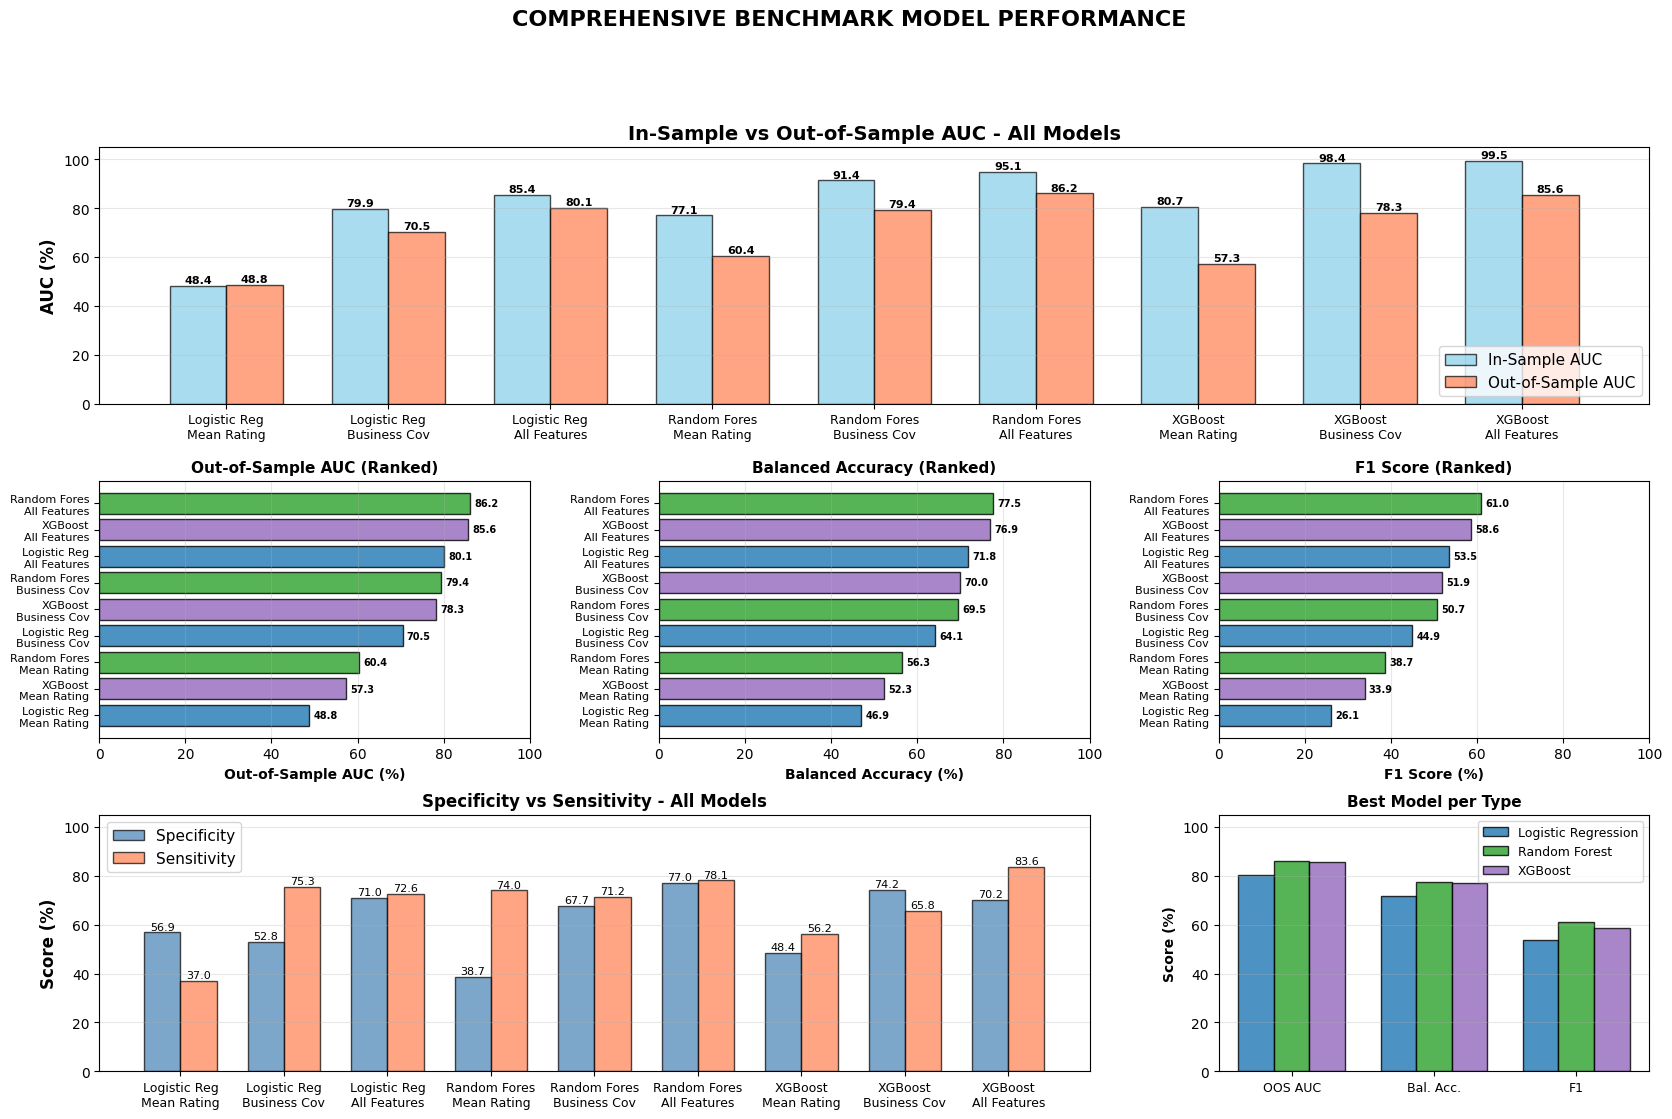

In [15]:
import matplotlib.pyplot as plt

# Comprehensive Visualization
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Farben für verschiedene Modelltypen
colors_map = {
    "Logistic Regression": "#1f77b4",
    "Random Forest": "#2ca02c",
    "XGBoost": "#9467bd",
}

# Modell-Labels für die Plots
model_labels = [
    f"{row['Model Type'][:12]}\n{row['Features'][:12]}"
    for _, row in comprehensive_performance.iterrows()
]
colors = [colors_map[mt] for mt in comprehensive_performance["Model Type"]]

# 1. In-Sample vs Out-of-Sample AUC (großer Plot oben)
ax1 = fig.add_subplot(gs[0, :])
x_pos = np.arange(len(model_labels))
width = 0.35

ax1.bar(
    x_pos - width / 2,
    comprehensive_performance["In-Sample AUC"].values,
    width,
    label="In-Sample AUC",
    alpha=0.7,
    color="skyblue",
    edgecolor="black",
)
ax1.bar(
    x_pos + width / 2,
    comprehensive_performance["Out-of-Sample AUC"].values,
    width,
    label="Out-of-Sample AUC",
    alpha=0.7,
    color="coral",
    edgecolor="black",
)

ax1.set_ylabel("AUC (%)", fontsize=12, fontweight="bold")
ax1.set_title(
    "In-Sample vs Out-of-Sample AUC - All Models", fontsize=14, fontweight="bold"
)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(model_labels, fontsize=9, rotation=0)
ax1.set_ylim([0, 105])
ax1.legend(fontsize=11, loc="lower right")
ax1.grid(axis="y", alpha=0.3)

# Werte über Balken
for i, (in_val, out_val) in enumerate(
    zip(
        comprehensive_performance["In-Sample AUC"].values,
        comprehensive_performance["Out-of-Sample AUC"].values,
    )
):
    ax1.text(
        i - width / 2,
        in_val + 1,
        f"{in_val:.1f}",
        ha="center",
        fontsize=8,
        fontweight="bold",
    )
    ax1.text(
        i + width / 2,
        out_val + 1,
        f"{out_val:.1f}",
        ha="center",
        fontsize=8,
        fontweight="bold",
    )

# 2. Out-of-Sample AUC (sortiert)
ax2 = fig.add_subplot(gs[1, 0])
sorted_labels = [
    f"{row['Model Type'][:12]}\n{row['Features'][:12]}"
    for _, row in comprehensive_performance_sorted.iterrows()
]
sorted_colors = [
    colors_map[mt] for mt in comprehensive_performance_sorted["Model Type"]
]

ax2.barh(
    range(len(sorted_labels)),
    comprehensive_performance_sorted["Out-of-Sample AUC"].values,
    color=sorted_colors,
    alpha=0.8,
    edgecolor="black",
)
ax2.set_yticks(range(len(sorted_labels)))
ax2.set_yticklabels(sorted_labels, fontsize=8)
ax2.set_xlabel("Out-of-Sample AUC (%)", fontsize=10, fontweight="bold")
ax2.set_title("Out-of-Sample AUC (Ranked)", fontsize=11, fontweight="bold")
ax2.set_xlim([0, 100])
ax2.grid(axis="x", alpha=0.3)
ax2.invert_yaxis()
for i, v in enumerate(comprehensive_performance_sorted["Out-of-Sample AUC"].values):
    ax2.text(v + 1, i, f"{v:.1f}", va="center", fontsize=7, fontweight="bold")

# 3. Balanced Accuracy
ax3 = fig.add_subplot(gs[1, 1])
sorted_by_bal = comprehensive_performance.sort_values(
    "Balanced Accuracy", ascending=False
)
sorted_labels_bal = [
    f"{row['Model Type'][:12]}\n{row['Features'][:12]}"
    for _, row in sorted_by_bal.iterrows()
]
sorted_colors_bal = [colors_map[mt] for mt in sorted_by_bal["Model Type"]]

ax3.barh(
    range(len(sorted_labels_bal)),
    sorted_by_bal["Balanced Accuracy"].values,
    color=sorted_colors_bal,
    alpha=0.8,
    edgecolor="black",
)
ax3.set_yticks(range(len(sorted_labels_bal)))
ax3.set_yticklabels(sorted_labels_bal, fontsize=8)
ax3.set_xlabel("Balanced Accuracy (%)", fontsize=10, fontweight="bold")
ax3.set_title("Balanced Accuracy (Ranked)", fontsize=11, fontweight="bold")
ax3.set_xlim([0, 100])
ax3.grid(axis="x", alpha=0.3)
ax3.invert_yaxis()
for i, v in enumerate(sorted_by_bal["Balanced Accuracy"].values):
    ax3.text(v + 1, i, f"{v:.1f}", va="center", fontsize=7, fontweight="bold")

# 4. F1 Score
ax4 = fig.add_subplot(gs[1, 2])
sorted_by_f1 = comprehensive_performance.sort_values("F1 Score", ascending=False)
sorted_labels_f1 = [
    f"{row['Model Type'][:12]}\n{row['Features'][:12]}"
    for _, row in sorted_by_f1.iterrows()
]
sorted_colors_f1 = [colors_map[mt] for mt in sorted_by_f1["Model Type"]]

ax4.barh(
    range(len(sorted_labels_f1)),
    sorted_by_f1["F1 Score"].values,
    color=sorted_colors_f1,
    alpha=0.8,
    edgecolor="black",
)
ax4.set_yticks(range(len(sorted_labels_f1)))
ax4.set_yticklabels(sorted_labels_f1, fontsize=8)
ax4.set_xlabel("F1 Score (%)", fontsize=10, fontweight="bold")
ax4.set_title("F1 Score (Ranked)", fontsize=11, fontweight="bold")
ax4.set_xlim([0, 100])
ax4.grid(axis="x", alpha=0.3)
ax4.invert_yaxis()
for i, v in enumerate(sorted_by_f1["F1 Score"].values):
    ax4.text(v + 1, i, f"{v:.1f}", va="center", fontsize=7, fontweight="bold")

# 5. Specificity vs Sensitivity (grouped)
ax5 = fig.add_subplot(gs[2, :2])
x_pos = np.arange(len(model_labels))
width = 0.35

ax5.bar(
    x_pos - width / 2,
    comprehensive_performance["Specificity"].values,
    width,
    label="Specificity",
    alpha=0.7,
    color="steelblue",
    edgecolor="black",
)
ax5.bar(
    x_pos + width / 2,
    comprehensive_performance["Sensitivity"].values,
    width,
    label="Sensitivity",
    alpha=0.7,
    color="coral",
    edgecolor="black",
)

ax5.set_ylabel("Score (%)", fontsize=12, fontweight="bold")
ax5.set_title("Specificity vs Sensitivity - All Models", fontsize=12, fontweight="bold")
ax5.set_xticks(x_pos)
ax5.set_xticklabels(model_labels, fontsize=9, rotation=0)
ax5.set_ylim([0, 105])
ax5.legend(fontsize=11)
ax5.grid(axis="y", alpha=0.3)

# Werte über Balken
for i, (spec, sens) in enumerate(
    zip(
        comprehensive_performance["Specificity"].values,
        comprehensive_performance["Sensitivity"].values,
    )
):
    ax5.text(i - width / 2, spec + 1, f"{spec:.1f}", ha="center", fontsize=8)
    ax5.text(i + width / 2, sens + 1, f"{sens:.1f}", ha="center", fontsize=8)

# 6. Model Type Comparison (Best of Each Type)
ax6 = fig.add_subplot(gs[2, 2])
best_per_type = comprehensive_performance.loc[
    comprehensive_performance.groupby("Model Type")["Out-of-Sample AUC"].idxmax()
]

metrics_to_compare = ["Out-of-Sample AUC", "Balanced Accuracy", "F1 Score"]
x_labels = ["OOS AUC", "Bal. Acc.", "F1"]
x_pos = np.arange(len(metrics_to_compare))
width = 0.25

for i, (idx, model) in enumerate(best_per_type.iterrows()):
    values = [model[m] for m in metrics_to_compare]
    ax6.bar(
        x_pos + i * width,
        values,
        width,
        label=model["Model Type"],
        alpha=0.8,
        color=colors_map[model["Model Type"]],
        edgecolor="black",
    )

ax6.set_ylabel("Score (%)", fontsize=10, fontweight="bold")
ax6.set_title("Best Model per Type", fontsize=11, fontweight="bold")
ax6.set_xticks(x_pos + width)
ax6.set_xticklabels(x_labels, fontsize=9)
ax6.set_ylim([0, 105])
ax6.legend(fontsize=9)
ax6.grid(axis="y", alpha=0.3)

plt.suptitle(
    "COMPREHENSIVE BENCHMARK MODEL PERFORMANCE", fontsize=16, fontweight="bold", y=0.995
)

plt.show()